In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv(
    "../datasets/processed/df_united_v2.csv"
)

In [4]:
df.head()

,url,label,source,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,...,Has_security,Has_support,SuspiciousTLD,ManySubdomains,KnownBrandInURL,SpecialCharRatio,LongURL,VeryLongURL,UrlEntropy,FreeHosting
0,https://start-ledggee-cdn.teachable.com/p/home,1,phishingdb,2,1,2,46,2,2,0,...,0,0,0,0,0,0.043478,0,0,4.058691,0
1,http://43.153.192.86/v3/signin/identifier?dsh=...,1,phishingdb,13,2,3,432,2,0,0,...,0,0,0,1,1,0.023148,1,1,5.703598,0
2,http://63179679.satgrjtxcvdv.org.cn/amagc,1,phishingdb,3,2,1,41,0,0,0,...,0,0,0,1,0,0.000000,0,0,4.338663,0
3,http://amber-kh.com/dollarman/ujhost/Account%2...,1,phishingdb,2,0,6,98,1,1,0,...,0,1,0,0,0,0.040816,1,0,4.633045,0
4,http://207.154.253.64/banks/CIBC/4fdb6096796be...,1,phishingdb,3,2,3,65,0,0,0,...,0,0,0,1,0,0.000000,0,0,4.512935,0


In [5]:
df.shape

(115934, 51)

In [6]:
df.columns.tolist()

['url',
 'label',
 'source',
 'NumDots',
 'SubdomainLevel',
 'PathLevel',
 'UrlLength',
 'NumDash',
 'NumDashInHostname',
 'AtSymbol',
 'TildeSymbol',
 'NumUnderscore',
 'NumPercent',
 'NumQueryComponents',
 'NumAmpersand',
 'NumHash',
 'NumNumericChars',
 'PctNumericChars',
 'NoHttps',
 'IpAddress',
 'DomainInSubdomains',
 'DomainInPaths',
 'HostnameLength',
 'PathLength',
 'QueryLength',
 'HttpsInHostname',
 'HostnameHasDigit',
 'HostnameDigitCount',
 'NumSensitiveWords',
 'DoubleSlashInPath',
 'Has_login',
 'Has_verify',
 'Has_secure',
 'Has_account',
 'Has_update',
 'Has_confirm',
 'Has_signin',
 'Has_bank',
 'Has_payment',
 'Has_wallet',
 'Has_password',
 'Has_security',
 'Has_support',
 'SuspiciousTLD',
 'ManySubdomains',
 'KnownBrandInURL',
 'SpecialCharRatio',
 'LongURL',
 'VeryLongURL',
 'UrlEntropy',
 'FreeHosting']

In [7]:
df["label"].value_counts()

label
1    57967
0    57967
Name: count, dtype: int64

In [8]:
df_train, df_holdout = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

In [9]:
print("Treino :", len(df_train))
print("Holdout:", len(df_holdout))

Treino : 92747
Holdout: 23187


In [10]:
df_train["label"].value_counts(normalize=True)

label
1    0.500005
0    0.499995
Name: proportion, dtype: float64

In [11]:
df_holdout["label"].value_counts(normalize=True)

label
0    0.500022
1    0.499978
Name: proportion, dtype: float64

In [12]:
X_train = df_train.drop(
    columns=[
        "label",
        "url",
        "source"
    ],
    errors="ignore"
)

y_train = df_train["label"]

X_test = df_holdout.drop(
    columns=[
        "label",
        "url",
        "source"
    ],
    errors="ignore"
)

y_test = df_holdout["label"]

In [13]:
X_train.select_dtypes(
    include=["object"]
).columns.tolist()

[]

In [14]:
print("Número de features:", X_train.shape[1])

Número de features: 48


In [15]:
X_train.columns.tolist()

['NumDots',
 'SubdomainLevel',
 'PathLevel',
 'UrlLength',
 'NumDash',
 'NumDashInHostname',
 'AtSymbol',
 'TildeSymbol',
 'NumUnderscore',
 'NumPercent',
 'NumQueryComponents',
 'NumAmpersand',
 'NumHash',
 'NumNumericChars',
 'PctNumericChars',
 'NoHttps',
 'IpAddress',
 'DomainInSubdomains',
 'DomainInPaths',
 'HostnameLength',
 'PathLength',
 'QueryLength',
 'HttpsInHostname',
 'HostnameHasDigit',
 'HostnameDigitCount',
 'NumSensitiveWords',
 'DoubleSlashInPath',
 'Has_login',
 'Has_verify',
 'Has_secure',
 'Has_account',
 'Has_update',
 'Has_confirm',
 'Has_signin',
 'Has_bank',
 'Has_payment',
 'Has_wallet',
 'Has_password',
 'Has_security',
 'Has_support',
 'SuspiciousTLD',
 'ManySubdomains',
 'KnownBrandInURL',
 'SpecialCharRatio',
 'LongURL',
 'VeryLongURL',
 'UrlEntropy',
 'FreeHosting']

In [16]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92747 entries, 105194 to 79999
Data columns (total 48 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NumDots             92747 non-null  int64  
 1   SubdomainLevel      92747 non-null  int64  
 2   PathLevel           92747 non-null  int64  
 3   UrlLength           92747 non-null  int64  
 4   NumDash             92747 non-null  int64  
 5   NumDashInHostname   92747 non-null  int64  
 6   AtSymbol            92747 non-null  int64  
 7   TildeSymbol         92747 non-null  int64  
 8   NumUnderscore       92747 non-null  int64  
 9   NumPercent          92747 non-null  int64  
 10  NumQueryComponents  92747 non-null  int64  
 11  NumAmpersand        92747 non-null  int64  
 12  NumHash             92747 non-null  int64  
 13  NumNumericChars     92747 non-null  int64  
 14  PctNumericChars     92747 non-null  float64
 15  NoHttps             92747 non-null  int64  
 16  IpAd

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
rf_pred = rf.predict(X_test)

In [19]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1       :", f1_score(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

Accuracy : 0.9991374477077672
Precision: 0.9990513152220785
Recall   : 0.9992236694557061
F1       : 0.9991374849059859

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11594
           1       1.00      1.00      1.00     11593

    accuracy                           1.00     23187
   macro avg       1.00      1.00      1.00     23187
weighted avg       1.00      1.00      1.00     23187


Confusion Matrix
[[11583    11]
 [    9 11584]]


In [20]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.head(20)

,Feature,Importance
0,HostnameLength,0.237805
1,DomainInPaths,0.204243
2,DomainInSubdomains,0.169802
3,SubdomainLevel,0.075837
4,HostnameDigitCount,0.071081
5,PathLength,0.036356
6,HostnameHasDigit,0.030877
7,SpecialCharRatio,0.024822
8,PathLevel,0.018592
9,NumDashInHostname,0.018191


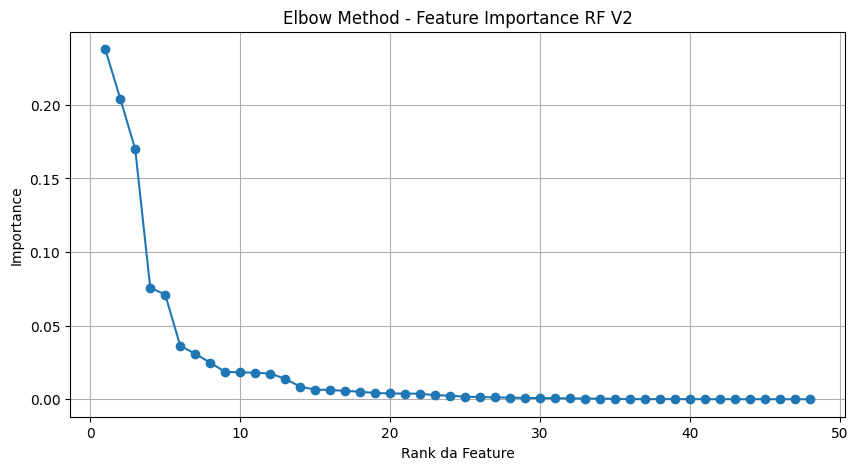

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(feature_importance)+1),
    feature_importance["Importance"],
    marker="o"
)

plt.xlabel("Rank da Feature")
plt.ylabel("Importance")
plt.title("Elbow Method - Feature Importance RF V2")

plt.grid(True)

plt.show()

In [ ]:
import joblib

joblib.dump(
    rf,
    "../models/scenario_3b1/rf_scenario_3b1.pkl"
)

joblib.dump(
    list(X_train.columns),
    "../artifacts/scenario_3b1/feature_columns_v2.pkl"
)

feature_importance.to_csv(
    "../artifacts/scenario_3b1/feature_importance_v2.csv",
    index=False
)